In [185]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from config.convolutional_features import TOTAL_CONV_OPS_PER_INPUT
from config.dense_features import DENSE_FEATURES
from config.pooling_features import TOTAL_POOLING_NO_OPS
import numpy as np

# Load data

In [16]:
training_data_path = Path("../training_data")

In [136]:
convolutional_data = {}
dense_data = {}
pooling_data = {}
for model_path in training_data_path.iterdir():
    if (model_path / "convolutional.csv").exists():
        convolutional_data[model_path.stem] = pd.read_csv(model_path / "convolutional.csv")
        convolutional_data[model_path.stem]["model"] = model_path.stem

    if (model_path / "dense.csv").exists():
        dense_data[model_path.stem] = pd.read_csv(model_path / "dense.csv")
        dense_data[model_path.stem]["model"] = model_path.stem

    if (model_path / "pooling.csv").exists():
        pooling_data[model_path.stem] = pd.read_csv(model_path / "pooling.csv")
        pooling_data[model_path.stem]["model"] = model_path.stem

convolutional_df = pd.concat(convolutional_data.values(), ignore_index=True)
dense_df = pd.concat(dense_data.values(), ignore_index=True)
pooling_df = pd.concat(pooling_data.values(), ignore_index=True)

In [169]:
convolutional_df["energy"] = convolutional_df["power"] * convolutional_df["runtime"]
pooling_df["energy"] = pooling_df["power"] * pooling_df["runtime"]
dense_df["energy"] = dense_df["power"] * dense_df["runtime"]


In [ ]:
convolutional_df["total_ops"] = convolutional_df.loc[:, TOTAL_CONV_OPS_PER_INPUT].agg("product", axis="columns")
dense_df["total_ops"] = dense_df.loc[:, DENSE_FEATURES].agg("product", axis="columns")
pooling_df["total_ops"] = pooling_df.loc[:, TOTAL_POOLING_NO_OPS].agg("product", axis="columns")

# Exploration
## Power distributions per layer

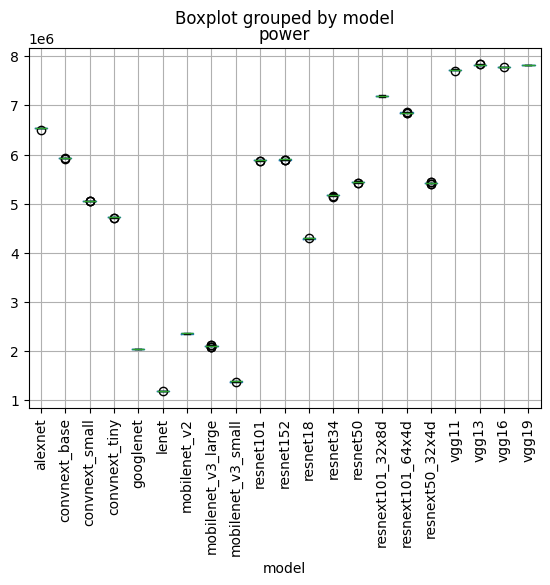

,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
alexnet,11.0,6.535155e+06,12311.576958,6.499484e+06,6.535426e+06,6.539229e+06,6.541039e+06,6.544575e+06
convnext_base,40.0,5.929281e+06,4186.235533,5.918645e+06,5.927748e+06,5.929917e+06,5.932246e+06,5.937044e+06
convnext_small,40.0,5.056527e+06,2985.793872,5.048186e+06,5.055154e+06,5.056776e+06,5.058323e+06,5.060865e+06
convnext_tiny,22.0,4.721145e+06,5208.501777,4.706170e+06,4.720030e+06,4.721913e+06,4.724601e+06,4.728848e+06
googlenet,1.0,2.051217e+06,NaN,2.051217e+06,2.051217e+06,2.051217e+06,2.051217e+06,2.051217e+06
lenet,7.0,1.182599e+06,2192.794233,1.178402e+06,1.182076e+06,1.182754e+06,1.184059e+06,1.184769e+06
mobilenet_v2,54.0,2.359994e+06,5511.197123,2.347049e+06,2.356157e+06,2.361041e+06,2.363793e+06,2.370875e+06
mobilenet_v3_large,73.0,2.108604e+06,7529.480054,2.090124e+06,2.105222e+06,2.108204e+06,2.112504e+06,2.128708e+06
mobilenet_v3_small,64.0,1.384291e+06,5796.260882,1.368372e+06,1.380282e+06,1.384370e+06,1.387953e+06,1.399123e+06


In [138]:
pd.concat([convolutional_df, dense_df, pooling_df]).boxplot(column=["power"], by='model')
plt.xticks(rotation=90)
plt.show()

model_summary_statistics = pd.concat([convolutional_df, dense_df, pooling_df]).groupby("model").power.describe()
display(model_summary_statistics)

Inference power is virtually the same for all layers within a given model

## Feature distributions

<Figure size 1200x1200 with 0 Axes>

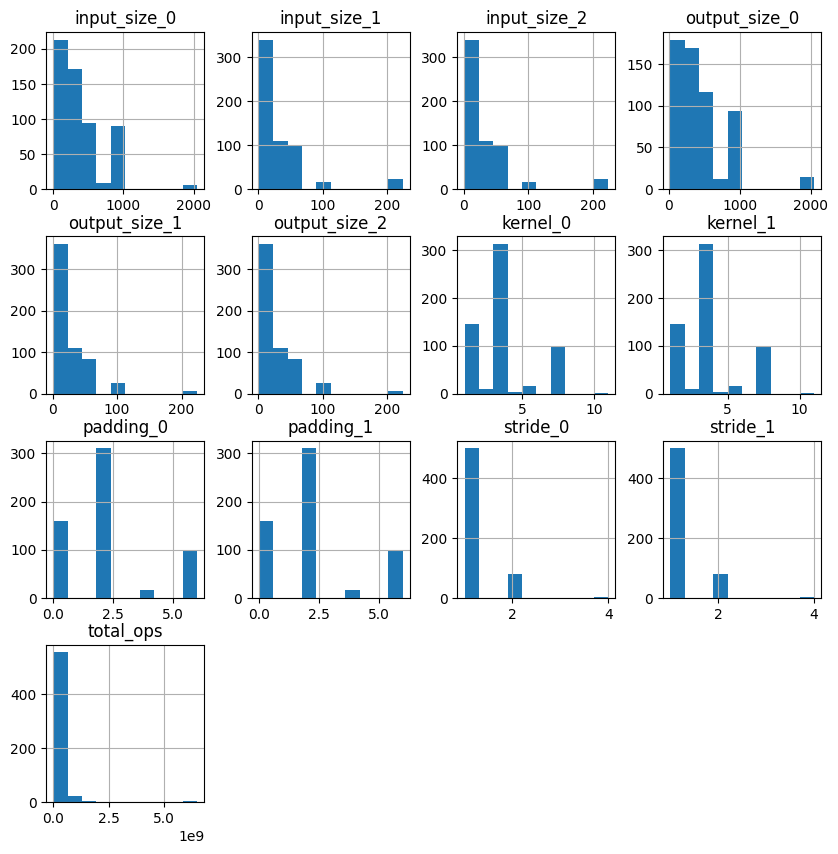

In [178]:
convolutional_df.drop(["model", "layer_name", "batch_size", "energy", "power", "runtime"], axis=1).hist(figsize=(10, 10))
plt.show()

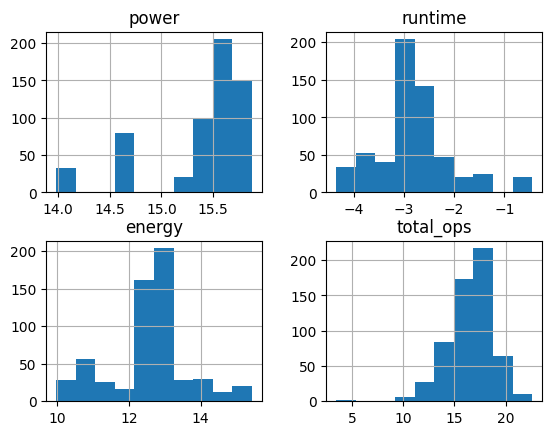

In [204]:
np.log(convolutional_df.loc[:, ["power", "runtime", "energy", "total_ops"]]).hist()
plt.show()

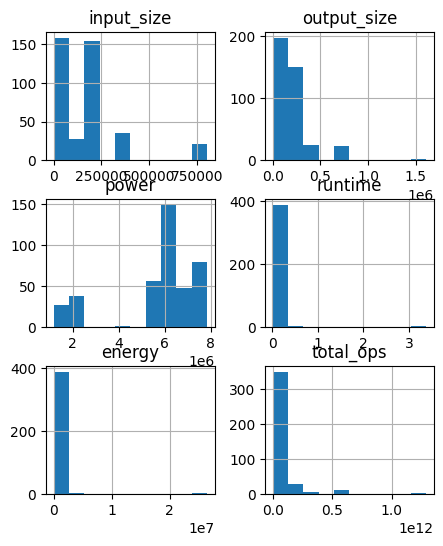

In [199]:
dense_df.drop(["model", "layer_name", "batch_size"], axis=1).hist(figsize=(5, 6))
plt.show()

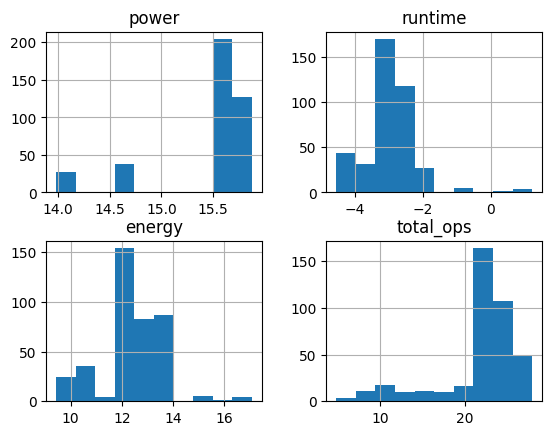

In [202]:
np.log(dense_df.loc[:, ["power", "runtime", "energy", "total_ops"]]).hist()
plt.show()

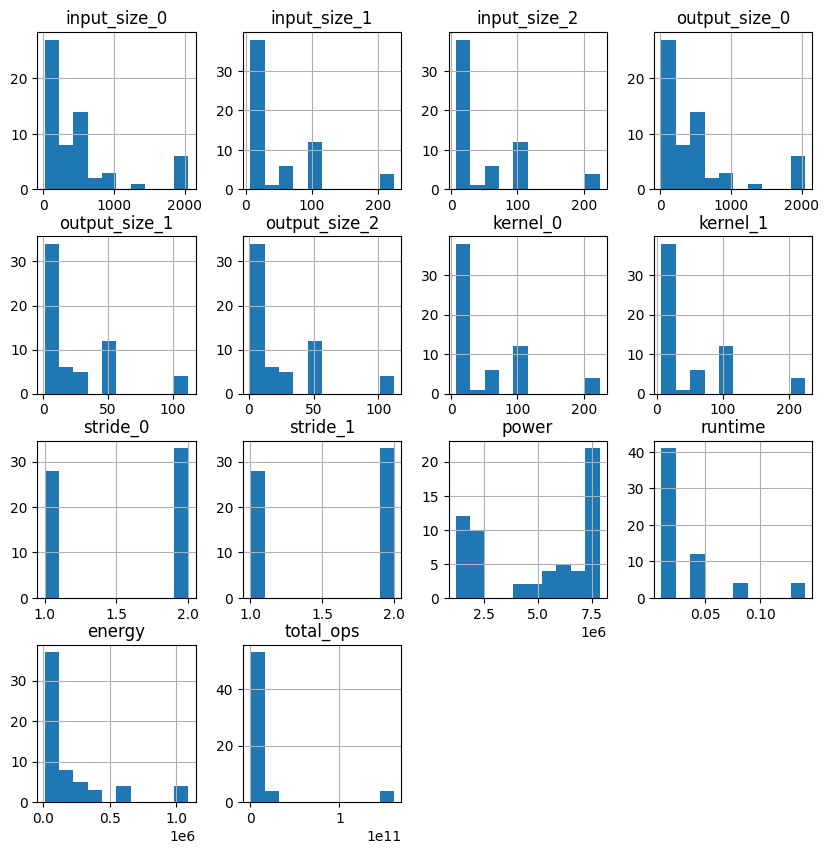

In [196]:
pooling_df.drop(["model", "layer_name", "batch_size"], axis=1).hist(figsize=(10, 10))
plt.show()

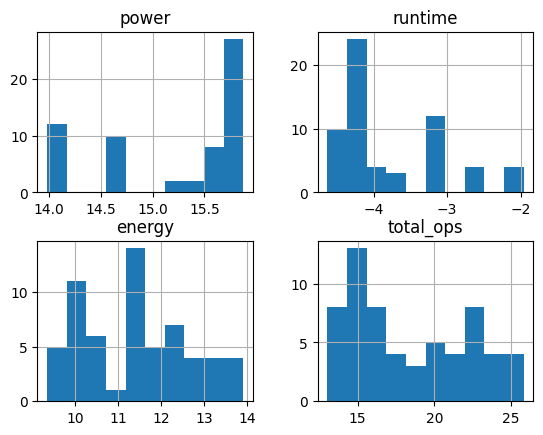

In [203]:
np.log(pooling_df.loc[:, ["power", "runtime", "energy", "total_ops"]]).hist()
plt.show()

## Correlations
### Number of layers

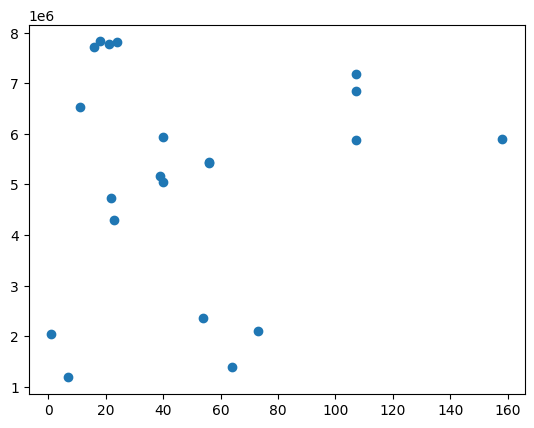

,count,mean
count,1.000000,0.102107
mean,0.102107,1.000000


In [207]:
plt.scatter(model_summary_statistics["count"], model_summary_statistics["mean"])

plt.show()
model_summary_statistics.loc[:, ["count", "mean"]].corr()

Layer count doesn't correlate with power

### Individual layers

In [214]:
convolutional_df.drop(["batch_size", "model", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size_0,0.332277,-0.057986,-0.024849
input_size_1,0.041061,0.295389,0.282053
input_size_2,0.041061,0.295389,0.282053
output_size_0,0.337975,-0.061443,-0.029888
output_size_1,0.098846,0.443859,0.432449
output_size_2,0.098846,0.443859,0.432449
kernel_0,0.107929,0.154005,0.090643
kernel_1,0.107929,0.154005,0.090643
padding_0,0.112242,0.161982,0.098344
padding_1,0.112242,0.161982,0.098344


- Low correlation between power and the features.
- Greater correlation between runtime and some of the features (including total operations).

In [218]:
dense_df.drop(["batch_size", "model", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size,0.386625,-0.064954,-0.062933
output_size,0.361169,-0.046763,-0.047950
total_ops,0.229494,-0.001120,-0.002459


In [219]:
dense_df.drop(["batch_size", "model", "layer_name"], axis=1).corr("spearman").loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size,0.430163,0.368165,0.393032
output_size,0.445362,0.585879,0.600536
total_ops,0.500256,0.551176,0.575185


- Low correlation between power and the features.
- Practically no correlation between runtime and the features.
- Correlation is better though, if we take Spearman instead of Pearson -> some data manipulation can still yield a good dense layer runtime model

In [220]:
pooling_df.drop(["batch_size", "model", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size_0,0.022882,-0.345976,-0.300647
input_size_1,0.471110,0.937248,0.910164
input_size_2,0.471110,0.937248,0.910164
output_size_0,0.022882,-0.345976,-0.300647
output_size_1,0.529935,0.933256,0.915745
output_size_2,0.529935,0.933256,0.915745
kernel_0,0.471110,0.937248,0.910164
kernel_1,0.471110,0.937248,0.910164
stride_0,0.731020,0.484833,0.532405
stride_1,0.731020,0.484833,0.532405


- Low correlation between power and the features, except stride for some reason.
- Greater correlation between runtime and some of the features (including total operations).

### Summed up layers in each model

In [222]:
def sum_up_model(df):
    new_df = df.groupby("model").sum()
    new_df["power"] = df.groupby("model").power.mean()
    return new_df

In [224]:
total_convolutional_df = sum_up_model(convolutional_df)
total_dense_df = sum_up_model(dense_df)
total_pooling_df = sum_up_model(pooling_df)


In [226]:
total_convolutional_df.drop(["batch_size", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size_0,0.249944,0.461061,0.380883
input_size_1,0.188716,0.479425,0.346330
input_size_2,0.188716,0.479425,0.346330
output_size_0,0.269750,0.475669,0.387010
output_size_1,0.278163,0.573133,0.472045
output_size_2,0.278163,0.573133,0.472045
kernel_0,0.115318,0.450468,0.249040
kernel_1,0.115318,0.450468,0.249040
padding_0,0.126416,0.433502,0.244965
padding_1,0.126416,0.433502,0.244965


- Lower correlation between power and individual features
- But quite high correlation between power and total number of operations

In [227]:
total_dense_df.drop(["batch_size", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size,0.282777,0.571846,0.466714
output_size,0.289091,0.592888,0.494995
total_ops,0.300576,0.609528,0.541889


- Same observations as with individual layers

In [228]:
total_pooling_df.drop(["batch_size", "layer_name"], axis=1).corr().loc[:, ["power", "runtime", "energy"]].drop(["power", "runtime", "energy"])

,power,runtime,energy
input_size_0,-0.192640,0.101139,-0.094134
input_size_1,0.643701,0.979600,0.986081
input_size_2,0.643701,0.979600,0.986081
output_size_0,-0.192640,0.101139,-0.094134
output_size_1,0.756915,0.901459,0.982708
output_size_2,0.756915,0.901459,0.982708
kernel_0,0.643701,0.979600,0.986081
kernel_1,0.643701,0.979600,0.986081
stride_0,0.211105,0.887203,0.745632
stride_1,0.211105,0.887203,0.745632


- There's a greater correlation between power and some features, namely total input, output and kernel sizes, and total operation.

Correlation between power and sums of individual features is pretty low

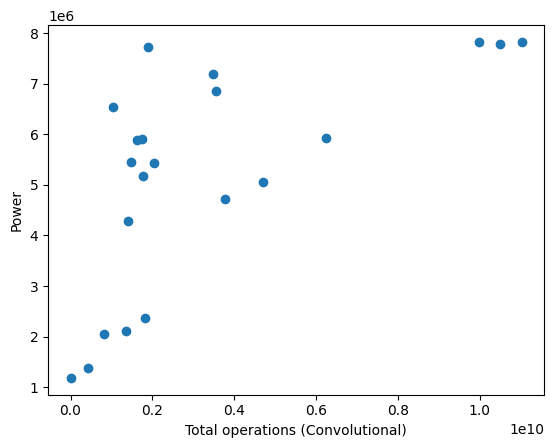

In [229]:
plt.scatter(total_convolutional_df.total_ops, total_convolutional_df.power)
plt.xlabel("Total operations (Convolutional)")
plt.ylabel("Power")
plt.show()

We can see a trend in convolutional layers

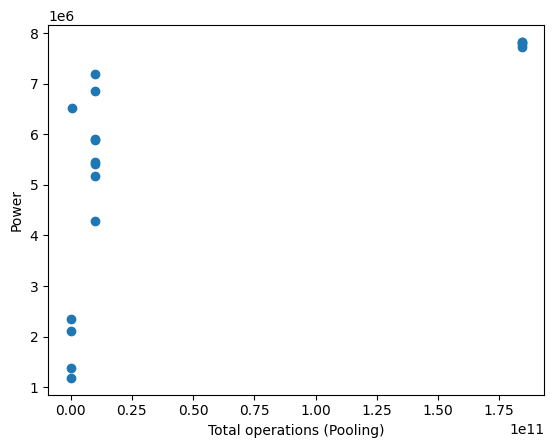

In [232]:
plt.scatter(total_pooling_df.total_ops, total_pooling_df.power)
plt.xlabel("Total operations (Pooling)")
plt.ylabel("Power")
plt.show()

But not so much in pooling layers

# Conclusions

- Power is indeed the same for all layers within a given network
- For convolutional and pooling layers, there's a very low correlation between individual layer features and power
- However, there's a noticeably greater correlation between total convolutional/pooling operations for the whole model and power
- This suggests that power depends on some notion of "overall size of the network"

Next steps:
- We need more (synthetic) data. Current dataset does not have many models, hence we cannot draw solid conclusions how parameters overall influence the model power (even though it looks like this is a correct direction)